# 04 — E-Perf-5: Cross-Architecture Comparison

> **PENDING CANONICAL PI RUN.** This notebook requires data from both
> macOS/x86 and Raspberry Pi 4 (ARM Cortex-A72) to compute meaningful
> cross-architecture ratios. Currently a scaffolded stub.

RFC-008 §E-Perf-5. Compares dimensionless overhead ratios (Wasm/Native)
across architectures to confirm that the isolation tax is consistent and
architecture-independent. Reports ratios, not absolute numbers, per D13.

**Expected data layout**:
```
eval/results/e-perf-5/
  rpi4-<ts>/
    native/run-{01..30}/percentiles.json
    wafer/run-{01..30}/percentiles.json
  x86-<ts>/
    native/run-{01..30}/percentiles.json
    wafer/run-{01..30}/percentiles.json
```

**Produces**: Figure 4 (cross-architecture overhead ratio bar chart).

**Statistical pipeline**: Per-architecture Wasm/Native ratio → Mann-Whitney
U test on ratio distributions → Bootstrap 95% CI → Cliff's Delta.

In [1]:
import json, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'eval').is_dir():
    REPO = REPO.parent

# Check for Pi data
rpi4_dirs = sorted(glob.glob(str(REPO / 'eval/results/e-perf-5/rpi4-*')))
x86_dirs = sorted(glob.glob(str(REPO / 'eval/results/e-perf-5/x86-*')))
macos_dirs = sorted(glob.glob(str(REPO / 'eval/results/e-perf-5/shakedown-macos-*')))

if not rpi4_dirs:
    print('⚠️  NO Pi DATA AVAILABLE — this notebook requires canonical runs on RPi 4.')
    print('   Expected: eval/results/e-perf-5/rpi4-<ts>/')
    print('   This notebook will produce empty figures until Pi data lands.')
    print()
    print('Available data:')
    print(f'  x86 dirs:   {len(x86_dirs)}')
    print(f'  macOS dirs: {len(macos_dirs)}')
    print(f'  rpi4 dirs:  {len(rpi4_dirs)}')
else:
    print(f'Pi data found: {rpi4_dirs[-1]}')

⚠️  NO Pi DATA AVAILABLE — this notebook requires canonical runs on RPi 4.
   Expected: eval/results/e-perf-5/rpi4-<ts>/
   This notebook will produce empty figures until Pi data lands.

Available data:
  x86 dirs:   0
  macOS dirs: 0
  rpi4 dirs:  0


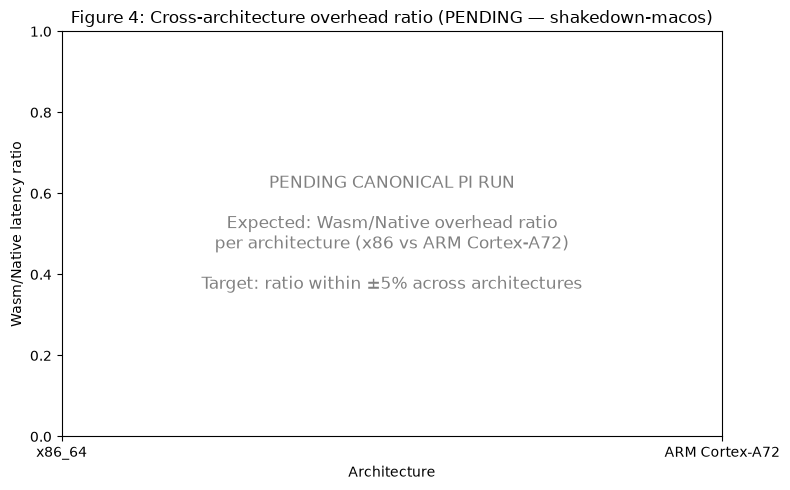

In [2]:
# Placeholder figure — empty axes with expected layout
fig, ax = plt.subplots(figsize=(8, 5))

# Expected: two groups (x86, ARM) with Wasm/Native ratio bars
ax.text(0.5, 0.5, 'PENDING CANONICAL PI RUN\n\n'
        'Expected: Wasm/Native overhead ratio\n'
        'per architecture (x86 vs ARM Cortex-A72)\n\n'
        'Target: ratio within ±5% across architectures',
        ha='center', va='center', fontsize=12, color='gray',
        transform=ax.transAxes)
ax.set_xlabel('Architecture')
ax.set_ylabel('Wasm/Native latency ratio')
ax.set_title('Figure 4: Cross-architecture overhead ratio (PENDING — shakedown-macos)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['x86_64', 'ARM Cortex-A72'])
plt.tight_layout()
plt.show()

## Status

This experiment cannot be completed on macOS shakedown alone. It requires:

1. **Raspberry Pi 4** running the same binary (cross-compiled `wasm32-wasip2`
   plugins are architecture-independent; the runtime must be compiled for
   `aarch64-unknown-linux-gnu`).
2. **x86_64 Linux** baseline (not macOS, to control for OS differences).
3. **Same pipeline config, same load profile** on both targets.

The macOS shakedown confirms the measurement rig works; the cross-arch
comparison itself is inherently a multi-platform experiment.

**Canonical-readiness**: blocked on Pi hardware availability. See
`docs/status/canonical-readiness.md` for the full gap analysis.